# Anomaly Class Exploration

**Key info:**
- `training_batch_with_labels` (Set 0): 2 anomaly sub-classes within label=1
- `first_batch_with_labels` (Set 1): additional anomaly sub-classes
- Combined (Set 0 + Set 1): 4 anomaly sub-classes total
- Both share the same label scheme (0=normal, 1=anomaly), so sub-classes are latent

**Goal:** Compress the sparse feature data into dense representations and visualize to uncover the hidden anomaly sub-clusters.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
# Set 0 = training_batch_with_labels (2 anomaly classes)
# Set 1 = first_batch_with_labels
# Set 2 = second_batch_with_labels
f_set0 = np.load("../../ORIGINAL MATS DONT MODIFY/training_batch_with_labels.npz")
f_set1 = np.load("../../ORIGINAL MATS DONT MODIFY/first_batch_with_labels.npz")
f_set2 = np.load("../../ORIGINAL MATS DONT MODIFY/second_batch_with_labels.npz")
f_set0_1 = np.load("../../ORIGINAL MATS DONT MODIFY/Labelled_0_1.npz")
f_set0_1_2 = np.load("../../ORIGINAL MATS DONT MODIFY/Labelled_0_1_2.npz")

print(
    "Set 0 - training_batch (2 anomaly classes) - X:",
    f_set0["X"].shape,
    "y:",
    f_set0["y"].shape,
)
print(
    "Set 1 - first_batch    (another 2 classes) - X:",
    f_set1["X"].shape,
    "y:",
    f_set1["y"].shape,
)
print(
    "Set 2 - second_batch   - X:",
    f_set2["X"].shape,
    "y:",
    f_set2["y"].shape,
)
print("Set 0 and 1 - combined - X:", f_set0_1["X"].shape, "y:", f_set0_1["y"].shape)
print(
    "Set 0, 1 and 2 - combined - X:", f_set0_1_2["X"].shape, "y:", f_set0_1_2["y"].shape
)


def _extract_labels(y):
    y = np.asarray(y)
    return y[:, 1] if y.ndim == 2 and y.shape[1] >= 2 else y.ravel()


print("=" * 100)
for name, y_raw in [
    ("Set 0", f_set0["y"]),
    ("Set 1", f_set1["y"]),
    ("Set 2", f_set2["y"]),
    ("Combined (Set 0 + Set 1)", f_set0_1["y"]),
    ("Combined (Set 0 + 1 + 2)", f_set0_1_2["y"]),
]:
    y_lbl = _extract_labels(y_raw)
    anomaly_pct = (y_lbl == 1).mean() * 100
    print(
        f"{name} anomaly percentage: {anomaly_pct:.2f}% ({(y_lbl == 1).sum()}/{len(y_lbl)})"
    )

Set 0 - training_batch (2 anomaly classes) - X: (177346, 3) y: (1100, 2)
Set 1 - first_batch    (another 2 classes) - X: (167493, 3) y: (1100, 2)
Set 2 - second_batch   - X: (134594, 3) y: (860, 2)
Set 0 and 1 - combined - X: (344839, 3) y: (2200, 2)
Set 0, 1 and 2 - combined - X: (479433, 3) y: (3060, 2)
Set 0 anomaly percentage: 9.09% (100/1100)
Set 1 anomaly percentage: 9.09% (100/1100)
Set 2 anomaly percentage: 6.98% (60/860)
Combined (Set 0 + Set 1) anomaly percentage: 9.09% (200/2200)
Combined (Set 0 + 1 + 2) anomaly percentage: 8.50% (260/3060)


In [3]:
# Count how many labels/ratings are actually 0 in the full combined labeled set
y_all_labels = _extract_labels(f_set0_1_2["y"])
n_zero_ratings = int((y_all_labels == 0).sum())

print(f"Number of ratings equal to 0: {n_zero_ratings}")
n_zero_ratings

Number of ratings equal to 0: 2800


2800

In [4]:
def sparse_to_dense(X_sparse, y_labels):
    """Convert (id, feature_idx, value) triplets to dense matrix + aligned labels.

    Unrated items stay at 0; observed ratings are stored as (rating + 1).
    """
    ids = np.unique(X_sparse[:, 0])
    id_to_row = {uid: i for i, uid in enumerate(ids)}

    n_samples = len(ids)
    n_features = X_sparse[:, 1].max() + 1

    dense = np.zeros((n_samples, n_features), dtype=np.float32)
    for row in X_sparse:
        dense[id_to_row[row[0]], row[1]] = row[2] + 1

    # Align labels
    label_dict = dict(y_labels)
    labels = np.array([label_dict[uid] for uid in ids])

    return dense, labels, ids


# Convert all sets
X0_dense, y0, ids0 = sparse_to_dense(f_set0["X"], f_set0["y"])
X1_dense, y1, ids1 = sparse_to_dense(f_set1["X"], f_set1["y"])
X2_dense, y2, ids2 = sparse_to_dense(f_set2["X"], f_set2["y"])

print(
    f"Set 0 (training_batch) dense: {X0_dense.shape}, anomalies: {y0.sum()}/{len(y0)}"
)
print(
    f"Set 1 (first_batch)    dense: {X1_dense.shape}, anomalies: {y1.sum()}/{len(y1)}"
)
print(
    f"Set 2 (second_batch)   dense: {X2_dense.shape}, anomalies: {y2.sum()}/{len(y2)}"
)

# Merge everything
X_all = np.concatenate([X0_dense, X1_dense, X2_dense], axis=0)
y_all = np.concatenate([y0, y1, y2], axis=0)
source = np.array(["set0"] * len(y0) + ["set1"] * len(y1) + ["set2"] * len(y2))

print(f"\nCombined dense: {X_all.shape} (All anomaly sub-classes total)")

Set 0 (training_batch) dense: (1100, 1000), anomalies: 100/1100
Set 1 (first_batch)    dense: (1100, 1000), anomalies: 100/1100
Set 2 (second_batch)   dense: (860, 1000), anomalies: 60/860

Combined dense: (3060, 1000) (All anomaly sub-classes total)


## 2. Label Distribution Comparison

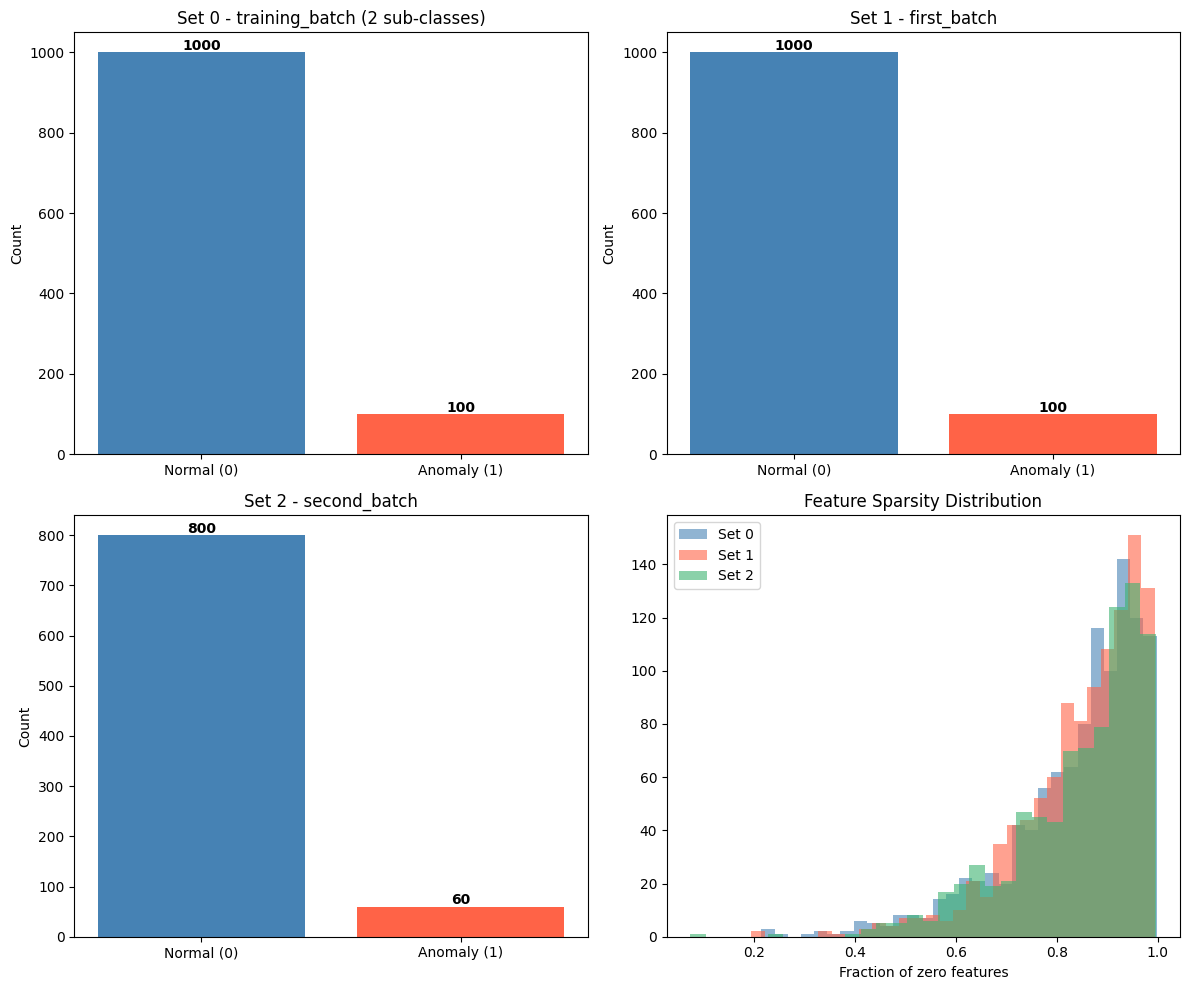

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()

# Per-set label counts
for ax, (name, labels) in zip(
    axes_flat[:3],
    [
        ("Set 0 - training_batch (2 sub-classes)", y0),
        ("Set 1 - first_batch", y1),
        ("Set 2 - second_batch", y2),
    ],
):
    vals, counts = np.unique(labels, return_counts=True)
    ax.bar(["Normal (0)", "Anomaly (1)"], counts, color=["steelblue", "tomato"])
    ax.set_title(name)
    ax.set_ylabel("Count")
    for i, (v, c) in enumerate(zip(vals, counts)):
        ax.text(i, c + 5, str(c), ha="center", fontweight="bold")

# Feature sparsity comparison
sparsity0 = (X0_dense == 0).mean(axis=1)
sparsity1 = (X1_dense == 0).mean(axis=1)
sparsity2 = (X2_dense == 0).mean(axis=1)


axes_flat[3].hist(sparsity0, bins=30, alpha=0.6, label="Set 0", color="steelblue")
axes_flat[3].hist(sparsity1, bins=30, alpha=0.6, label="Set 1", color="tomato")
axes_flat[3].hist(sparsity2, bins=30, alpha=0.6, label="Set 2", color="mediumseagreen")
axes_flat[3].set_title("Feature Sparsity Distribution")
axes_flat[3].set_xlabel("Fraction of zero features")
axes_flat[3].legend()

plt.tight_layout()
plt.show()

# trying out KDE PLots (Kernel Density Estimates)

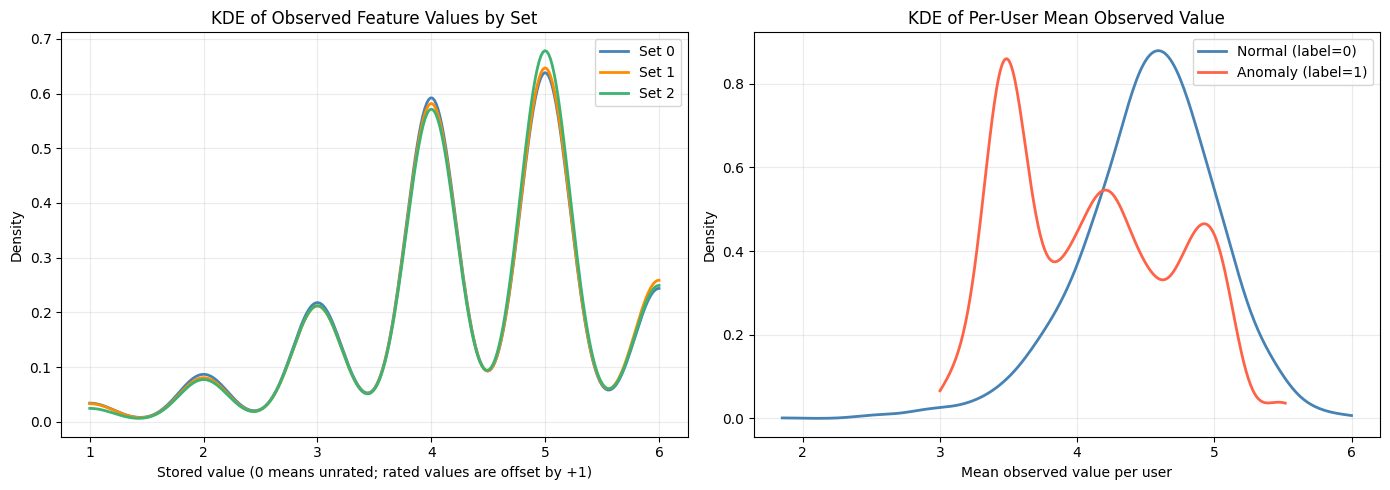

KDE plots generated:
1) Observed value density by source set
2) Per-user mean observed value density by label


In [7]:
from sklearn.neighbors import KernelDensity

# KDE plots for rating structure after offset encoding:
# 0 = unrated, observed rating stored as (original_rating + 1).

def kde_curve(values, grid_min=None, grid_max=None, bandwidth=0.2, n_points=300):
    values = np.asarray(values, dtype=float).ravel()
    values = values[np.isfinite(values)]
    if values.size < 2:
        return None, None

    if grid_min is None:
        grid_min = values.min()
    if grid_max is None:
        grid_max = values.max()
    if np.isclose(grid_min, grid_max):
        grid_min -= 0.5
        grid_max += 0.5

    grid = np.linspace(grid_min, grid_max, n_points).reshape(-1, 1)
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(values.reshape(-1, 1))
    density = np.exp(kde.score_samples(grid))
    return grid.ravel(), density

# Split row indices by source set
idx_set0 = source == "set0"
idx_set1 = source == "set1"
idx_set2 = source == "set2"

# 1) KDE of observed (non-zero) entry values by source set
obs0 = X0_dense[X0_dense > 0]
obs1 = X1_dense[X1_dense > 0]
obs2 = X2_dense[X2_dense > 0]

all_obs = np.concatenate([obs0, obs1, obs2]) if (len(obs0) + len(obs1) + len(obs2)) else np.array([])
x_min = all_obs.min() if all_obs.size else 0.0
x_max = all_obs.max() if all_obs.size else 1.0

# 2) Per-user mean observed rating (ignore zeros), split by label
safe_counts = np.maximum((X_all > 0).sum(axis=1), 1)
row_mean_observed = X_all.sum(axis=1) / safe_counts

mean_normal = row_mean_observed[y_all == 0]
mean_anomaly = row_mean_observed[y_all == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: observed rating value KDE by set
for vals, color, name in [
    (obs0, "steelblue", "Set 0"),
    (obs1, "darkorange", "Set 1"),
    (obs2, "mediumseagreen", "Set 2"),
]:
    gx, gy = kde_curve(vals, grid_min=x_min, grid_max=x_max, bandwidth=0.22)
    if gx is not None:
        axes[0].plot(gx, gy, color=color, linewidth=2, label=name)

axes[0].set_title("KDE of Observed Feature Values by Set")
axes[0].set_xlabel("Stored value (0 means unrated; rated values are offset by +1)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Right: per-user mean observed rating KDE by label
for vals, color, name in [
    (mean_normal, "steelblue", "Normal (label=0)"),
    (mean_anomaly, "tomato", "Anomaly (label=1)"),
]:
    gx, gy = kde_curve(vals, bandwidth=0.12)
    if gx is not None:
        axes[1].plot(gx, gy, color=color, linewidth=2, label=name)

axes[1].set_title("KDE of Per-User Mean Observed Value")
axes[1].set_xlabel("Mean observed value per user")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("KDE plots generated:")
print("1) Observed value density by source set")
print("2) Per-user mean observed value density by label")